In [199]:
import pandas as pd
import missingno as msno
from sklearn.model_selection import train_test_split
from missforest import MissForest
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from sklearn.inspection import permutation_importance
import shap
import lightgbm as lgb
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, median_absolute_error, mean_absolute_percentage_error,roc_auc_score



In [74]:
df=pd.read_csv("/workspaces/jovegom-intro-ml/data/bank-marketing-campaign-data.csv",sep=';')
df=df.rename(columns={'marital':'estado_civil','default':'tiene_credito','housing':'credito_vivienda','loan':'credito_persoanl','month':'ulti_mes_contac','day_of_week':'ultimo_dia_contac','duration':'duracion_contac','campaign':'n_contac','y':'deposito_largo_plazo'})

In [75]:
df

,age,job,estado_civil,education,tiene_credito,credito_vivienda,credito_persoanl,contact,ulti_mes_contac,ultimo_dia_contac,...,n_contac,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,deposito_largo_plazo
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.100,93.994,-36.400,4.857,5191.000,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,73,retired,married,professional.course,no,yes,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,yes
41184,46,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,no
41185,56,retired,married,university.degree,no,yes,no,cellular,nov,fri,...,2,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,no
41186,44,technician,married,professional.course,no,no,no,cellular,nov,fri,...,1,999,0,nonexistent,-1.100,94.767,-50.800,1.028,4963.600,yes


# Identificamos valores unicos

In [76]:
valores_unicos=df.nunique()
valores_unicos

age                       78
job                       12
estado_civil               4
education                  8
tiene_credito              3
credito_vivienda           3
credito_persoanl           3
contact                    2
ulti_mes_contac           10
ultimo_dia_contac          5
duracion_contac         1544
n_contac                  42
pdays                     27
previous                   8
poutcome                   3
emp.var.rate              10
cons.price.idx            26
cons.conf.idx             26
euribor3m                316
nr.employed               11
deposito_largo_plazo       2
dtype: int64

No tenemos valores unicos

# Filas y columnas duplicadas

In [77]:
# Filas duplicadas
df.duplicated().sum()

np.int64(12)

In [78]:
# Tenemos 12 duplicados los cuales eliminamos
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [79]:
df.T.duplicated().sum()

np.int64(0)

No tenemos columnas duplicadas

# Valores Faltantes

In [80]:
promedio_faltantes=df.isna().mean()*100
faltantes = ["no hay valores faltantes"] if any(n == 0 for n in promedio_faltantes) else promedio_faltantes
faltantes


['no hay valores faltantes']

## Valores faltantes enmascarados   

In [81]:
# traemos el Df con solo columnas categoricas
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
unknown_counts = df_cate.apply(lambda col: (col == "unknown").sum())
# sacamos el porcentaje de unknown
unknown_porce= df_cate.apply(lambda col: (col == "unknown").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'unknown_counts':unknown_counts,'unknown_porcentaje':unknown_porce}).sort_values(by='unknown_counts',ascending=False)
df_result

,unknown_counts,unknown_porcentaje
tiene_credito,8596,20.876
education,1730,4.201
credito_vivienda,990,2.404
credito_persoanl,990,2.404
job,330,0.801
estado_civil,80,0.194
contact,0,0.000
ulti_mes_contac,0,0.000
ultimo_dia_contac,0,0.000
poutcome,0,0.000


deacuerdo a lo anterior se decide eliminar los datos que tienen menos del 1% y se pone en consideracion mas adelante los que tienen un 2.4%

In [82]:
df_cate = df.select_dtypes(include=['object'])
# sacamos la cantidad de unknown por columna
nonexistent_counts = df_cate.apply(lambda col: (col == "nonexistent").sum())
# sacamos el porcentaje de unknown
nonexistent_porce= df_cate.apply(lambda col: (col == "nonexistent").mean()*100)
# creamos un DF con esta info
df_result=pd.DataFrame({'nonexistent_counts':nonexistent_counts,'nonexistent_porcentaje':nonexistent_porce}).sort_values(by='nonexistent_counts',ascending=False)
df_result

,nonexistent_counts,nonexistent_porcentaje
poutcome,35551,86.339
estado_civil,0,0.000
job,0,0.000
education,0,0.000
tiene_credito,0,0.000
credito_persoanl,0,0.000
credito_vivienda,0,0.000
contact,0,0.000
ulti_mes_contac,0,0.000
ultimo_dia_contac,0,0.000


Eliminamos la columna poutcome, ya que en su mayoria no posee datos que nos aporte al modelo

In [83]:
df = df.drop('poutcome', axis=1)

In [84]:
df=df[df['job']!='unknown']
df=df[df['estado_civil']!='unknown']
unknown_counts = df[['job','estado_civil']].apply(lambda col: (col == "unknown").sum())
unknown_counts

job             0
estado_civil    0
dtype: int64

<Axes: >

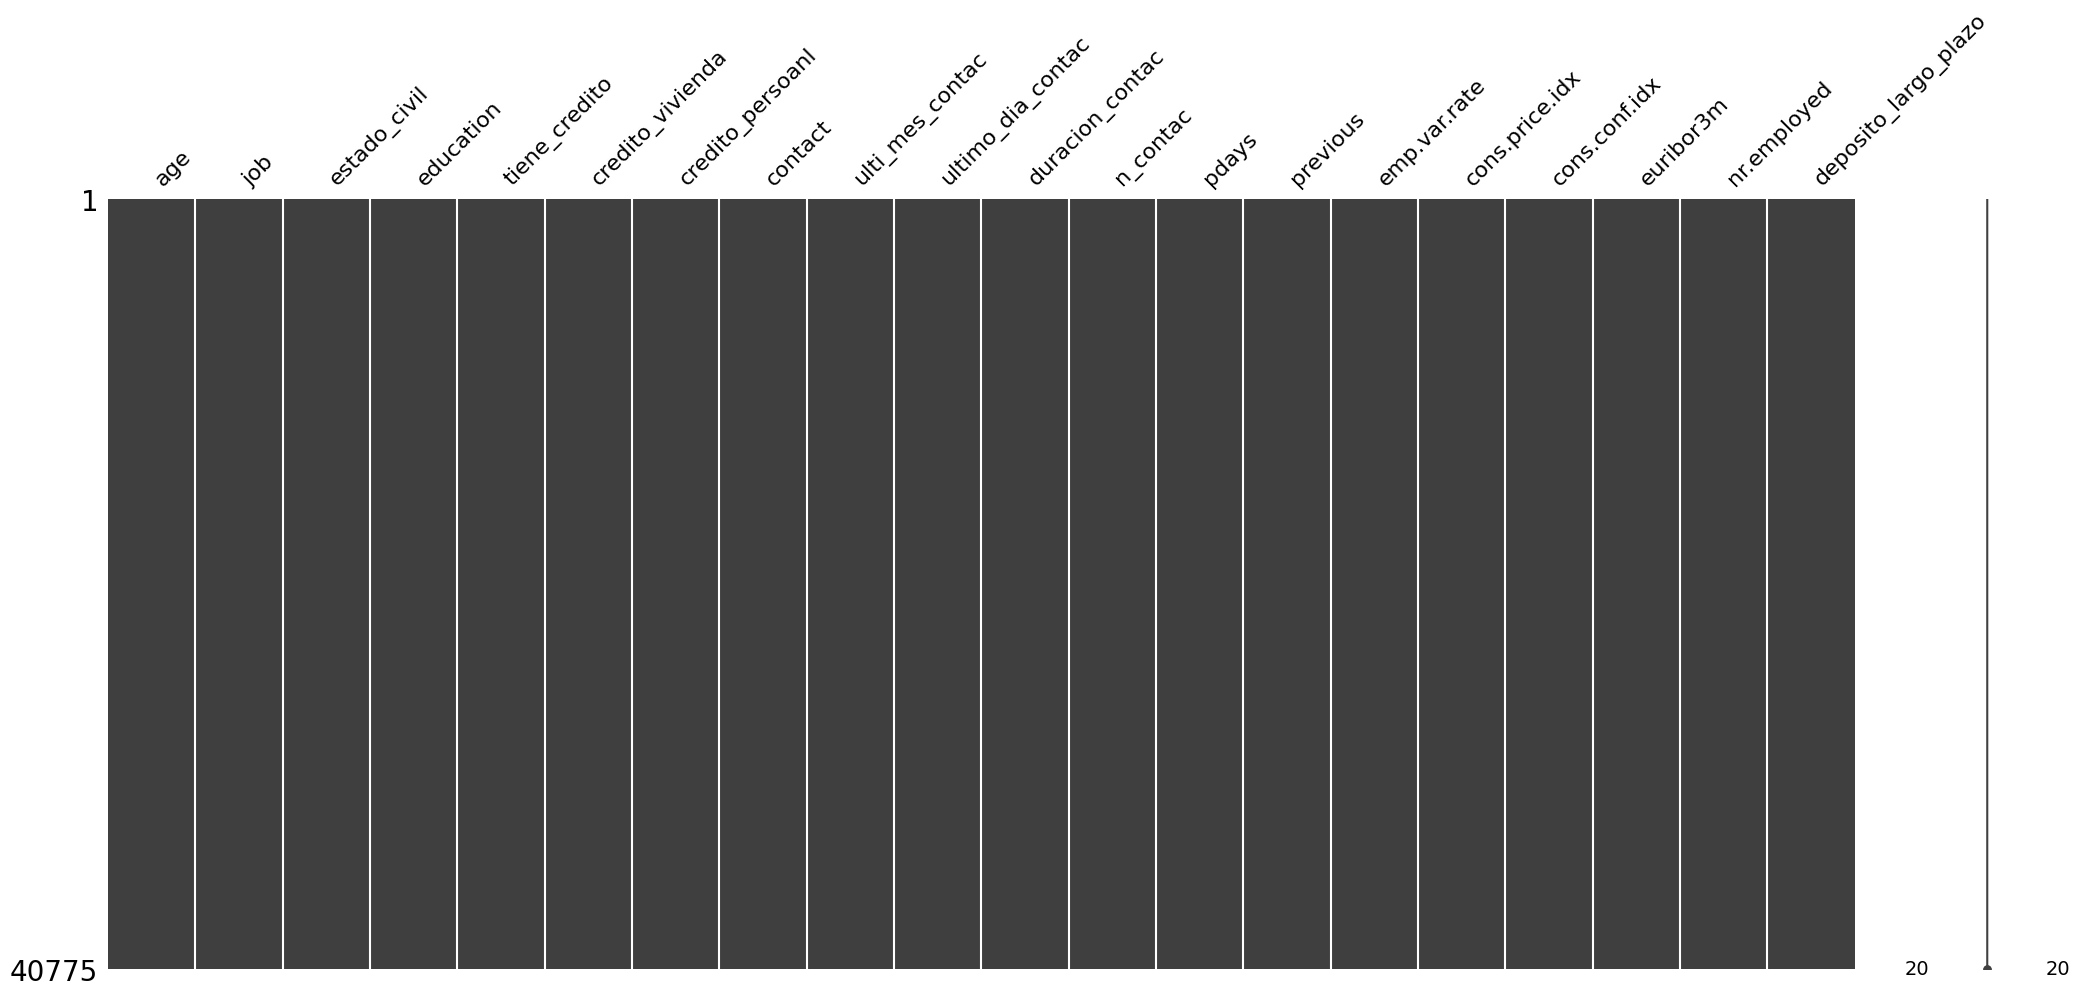

In [85]:
msno.matrix(df)

# Codificar variables categóricas.

In [86]:

# Identificar columnas categóricas
cat_cols = df.select_dtypes(include=['object']).columns

# Contar categorías por columna
num_categories = df[cat_cols].nunique()

# Dividir columnas según número de categorías
onehot_cols = num_categories[num_categories <= 4].index.tolist()
freq_cols   = num_categories[num_categories > 4].index.tolist()

# Aplicar one-hot encoding a las columnas pequeñas
df_onehot = pd.get_dummies(df[onehot_cols], drop_first=True, dtype=int)

# Aplicar frequency encoding a las columnas grandes
df_freq = df[freq_cols].copy()
for col in df_freq.columns:
    freq = df_freq[col].value_counts()
    df_freq[col] = df_freq[col].map(freq)

# Combinar todo con las columnas numéricas restantes
num_cols = df.select_dtypes(exclude=['object']).columns
df = pd.concat([df[num_cols], df_onehot, df_freq], axis=1)


# Train test split

In [87]:
X= df.drop('deposito_largo_plazo_yes',axis=1)
y= df['deposito_largo_plazo_yes']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Outliers

In [88]:
pd.set_option('display.float_format', '{:.3f}'.format)
X_train.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32620.000,39.972,10.382,17.000,32.000,38.000,47.000,98.000
duracion_contac,32620.000,258.068,258.170,0.000,102.000,179.000,320.000,3785.000
n_contac,32620.000,2.576,2.763,1.000,1.000,2.000,3.000,56.000
pdays,32620.000,962.808,186.086,0.000,999.000,999.000,999.000,999.000
previous,32620.000,0.171,0.489,0.000,0.000,0.000,0.000,6.000
emp.var.rate,32620.000,0.084,1.570,-3.400,-1.800,1.100,1.400,1.400
cons.price.idx,32620.000,93.576,0.578,92.201,93.075,93.749,93.994,94.767
cons.conf.idx,32620.000,-40.526,4.625,-50.800,-42.700,-41.800,-36.400,-26.900
euribor3m,32620.000,3.622,1.734,0.634,1.344,4.857,4.961,5.045
nr.employed,32620.000,5167.191,72.170,4963.600,5099.100,5191.000,5228.100,5228.100


In [89]:
iso = IsolationForest(random_state=123)
df_num = X_train.copy()
df_num['outlier_flag'] = iso.fit_predict(X_train)
df_num['outlier_flag'].value_counts()

outlier_flag
 1    22455
-1    10165
Name: count, dtype: int64

# Seleccion de caracteristicas

## Método 1 Feature importance de RF

In [90]:
# Entrenamiento de RF
model = RandomForestClassifier(random_state=42,n_jobs=-1).fit(X_train, y_train)
# Importancia de características
importances = model.feature_importances_/model.feature_importances_.sum()*100
# Convertir a DataFrame
df_rf_imp = pd.DataFrame({'feature': X_train.columns,'rf_importance': importances}).sort_values(by='rf_importance', ascending=False)
# Calculamos la importancia acumulada
df_rf_imp['rf_importance_acum'] = df_rf_imp['rf_importance'].cumsum()
df_rf_imp

,feature,rf_importance,rf_importance_acum
1,duracion_contac,31.233,31.233
8,euribor3m,11.353,42.587
0,age,9.425,52.012
9,nr.employed,5.667,57.679
19,job,5.067,62.746
20,education,4.417,67.163
2,n_contac,4.336,71.499
3,pdays,4.221,75.720
22,ultimo_dia_contac,3.988,79.708
21,ulti_mes_contac,2.860,82.569


## Metodo 2 Permutation/Shuffle importance

In [91]:
# Para esta técnica y la de shap se necesita conjunto de validación
X_train1, X_val, y_train1, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Ajustamos el modelo
model_xgb = XGBClassifier(objective='binary:logistic',random_state=42,use_label_encoder=False,eval_metric='logloss').fit(X_train1, y_train1)

# Realizamos 10 permutaciones por cada característica (se usa neg_mean_absolute_error)
perm = permutation_importance(model_xgb, X_val, y_val, n_repeats=10, random_state=42, n_jobs=-1, scoring='accuracy')

df_perm_imp = pd.DataFrame({'feature': X_train.columns, 'perm_imp': perm.importances_mean*100}).sort_values('perm_imp', ascending=False)
df_perm_imp

/home/vscode/.local/lib/python3.11/site-packages/xgboost/training.py:199: UserWarning: [19:57:40] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,feature,perm_imp
1,duracion_contac,5.846
8,euribor3m,1.438
9,nr.employed,0.946
5,emp.var.rate,0.898
3,pdays,0.723
21,ulti_mes_contac,0.501
18,contact_telephone,0.400
0,age,0.333
20,education,0.305
19,job,0.241


## Metodo 3 SHAP

In [92]:
# Ajustamos el modelo
model_lgbm = lgb.LGBMClassifier(random_state=42, n_jobs=-1).fit(X_train, y_train)

explainer = shap.Explainer(model_lgbm, X_val)   # usa el mismo X_val
shap_vals = explainer(X_val).values

imp_shap = np.abs(shap_vals).mean(axis=0)
imp_shap_pct = imp_shap/imp_shap.sum()*100
df_shap_imp = pd.DataFrame({"feature": X_val.columns, "shap_imp": imp_shap_pct}).sort_values('shap_imp', ascending=False)
df_shap_imp

[LightGBM] [Info] Number of positive: 3651, number of negative: 28969
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.024384 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 726
[LightGBM] [Info] Number of data points in the train set: 32620, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111925 -> initscore=-2.071225
[LightGBM] [Info] Start training from score -2.071225


 99%|===================| 6472/6524 [00:15<00:00]        

,feature,shap_imp
1,duracion_contac,39.922
5,emp.var.rate,19.869
21,ulti_mes_contac,9.105
8,euribor3m,8.044
9,nr.employed,5.415
12,tiene_credito_unknown,2.798
6,cons.price.idx,2.477
18,contact_telephone,2.410
0,age,2.053
2,n_contac,1.669


## Union de metodos

In [93]:
df_importances = (
    df_rf_imp
    .merge(df_perm_imp, on='feature', how='outer')
    .merge(df_shap_imp, on='feature', how='outer')
).sort_values('rf_importance', ascending=False)
df_importances

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duracion_contac,31.233,31.233,5.846,39.922
13,euribor3m,11.353,42.587,1.438,8.044
0,age,9.425,52.012,0.333,2.053
16,nr.employed,5.667,57.679,0.946,5.415
14,job,5.067,62.746,0.241,0.787
9,education,4.417,67.163,0.305,0.798
15,n_contac,4.336,71.499,0.207,1.669
17,pdays,4.221,75.720,0.723,0.973
22,ultimo_dia_contac,3.988,79.708,0.201,1.091
21,ulti_mes_contac,2.860,82.569,0.501,9.105


## Caracteristicas seleccionadas

In [103]:
df_filt = df_importances[(df_importances['rf_importance']>=2)|(df_importances['perm_imp']>=2)|(df_importances['shap_imp']>=2)]
df_filt

,feature,rf_importance,rf_importance_acum,perm_imp,shap_imp
8,duracion_contac,31.233,31.233,5.846,39.922
13,euribor3m,11.353,42.587,1.438,8.044
0,age,9.425,52.012,0.333,2.053
16,nr.employed,5.667,57.679,0.946,5.415
14,job,5.067,62.746,0.241,0.787
9,education,4.417,67.163,0.305,0.798
15,n_contac,4.336,71.499,0.207,1.669
17,pdays,4.221,75.720,0.723,0.973
22,ultimo_dia_contac,3.988,79.708,0.201,1.091
21,ulti_mes_contac,2.860,82.569,0.501,9.105


### VIF

In [105]:
features = df_filt['feature']
features

8           duracion_contac
13                euribor3m
0                       age
16              nr.employed
14                      job
9                 education
15                 n_contac
17                    pdays
22        ultimo_dia_contac
21          ulti_mes_contac
10             emp.var.rate
1             cons.conf.idx
2            cons.price.idx
3         contact_telephone
19    tiene_credito_unknown
Name: feature, dtype: object

In [106]:
vif = pd.Series([variance_inflation_factor(X_train[features].corr().values, i) for i in range(X_train[features].corr().shape[1])], index=X_train[features].columns)
df_vif = pd.Series(vif, name='vif').reset_index().rename(columns={'index': 'feature'})
df_vif_filt=pd.merge(df_vif, df_filt, on='feature' ,how='inner')
df_vif_filt

,feature,vif,rf_importance,rf_importance_acum,perm_imp,shap_imp
0,duracion_contac,1.110,31.233,31.233,5.846,39.922
1,euribor3m,23372.172,11.353,42.587,1.438,8.044
2,age,1.514,9.425,52.012,0.333,2.053
3,nr.employed,8155.177,5.667,57.679,0.946,5.415
4,job,1.404,5.067,62.746,0.241,0.787
5,education,1.447,4.417,67.163,0.305,0.798
6,n_contac,2.073,4.336,71.499,0.207,1.669
7,pdays,2.794,4.221,75.720,0.723,0.973
8,ultimo_dia_contac,1.077,3.988,79.708,0.201,1.091
9,ulti_mes_contac,18.823,2.860,82.569,0.501,9.105


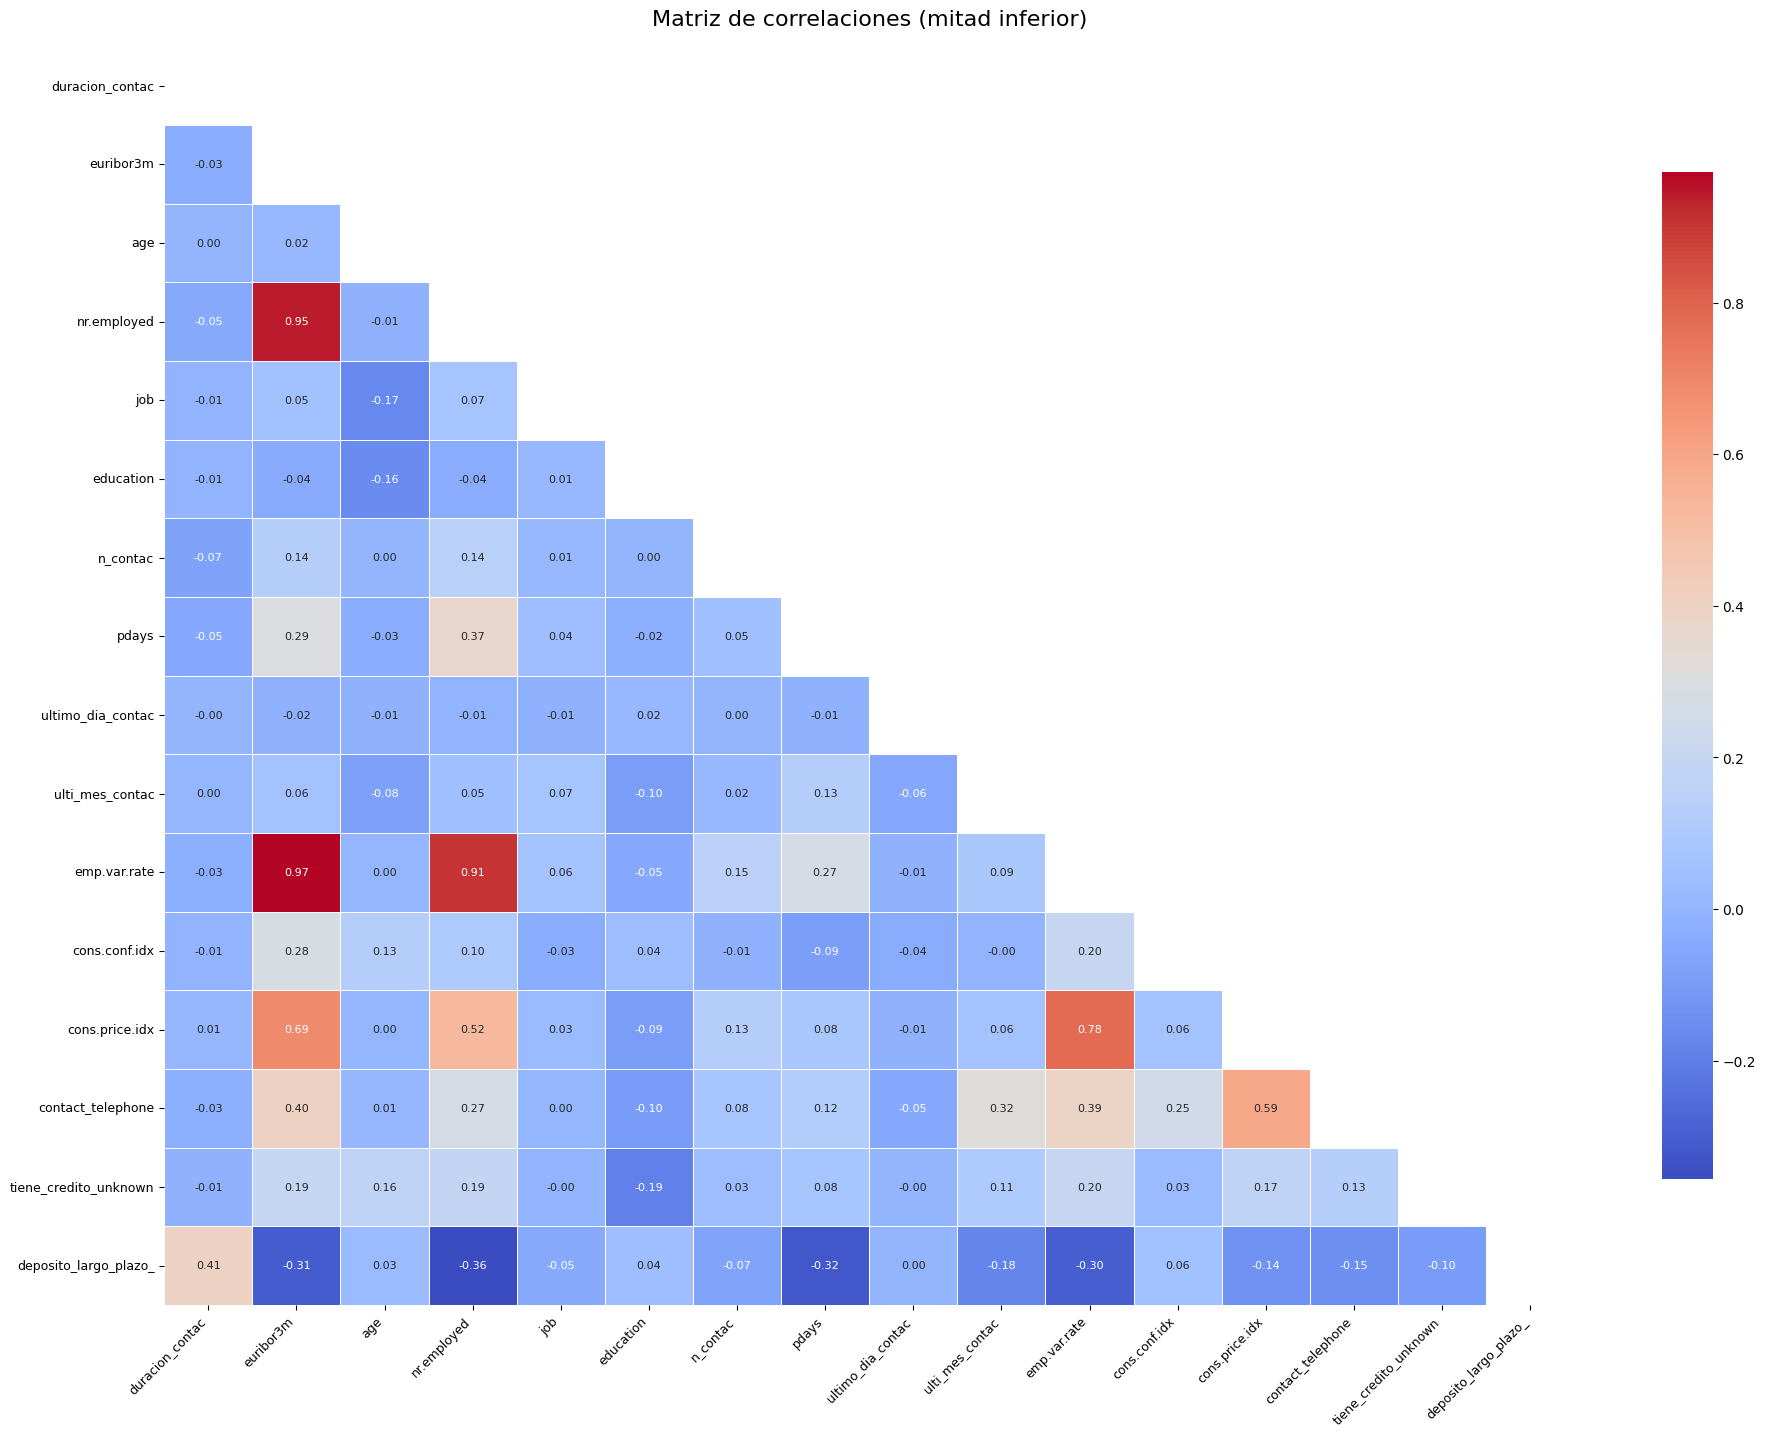

In [107]:
X_copy = X_train[features].copy()
X_copy['deposito_largo_plazo_'] = y_train
corr = X_copy.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(20, 15))
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 8}
)
plt.title("Matriz de correlaciones (mitad inferior)", fontsize=16, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout(pad=3.0)
plt.show()

## Cross_validation

In [108]:
# Versión 1: Realizar cross_validation con todas las características que son candidatas
cv_results1 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train[features], y_train, cv=3, scoring='accuracy')
cv_results1.mean()*1

np.float64(0.916063737150704)

In [133]:
# Versión 2: Realizar cross_validation con  las características que son candidatas sin las correlacionadas
cv_results2 = cross_val_score(RandomForestClassifier(random_state=42,n_jobs=-1), X_train[features].drop(['nr.employed','cons.price.idx','cons.conf.idx',],axis=1), y_train, cv=3, scoring='accuracy')
cv_results2.mean()*1

np.float64(0.9167075280724074)

Al realizar el Croos validation realizamos diferente convinaciones, eliminando aquellas caracteristicas que presentan mayor vif y la mejor convinancion fue la version 2, por ende decidimos continuar con estas caracteristicas.

In [129]:
# Selecciona la caracteristicas con las que hemos determinado que vamos a proseguir el análisis
X_train_sel = X_train[features].drop(['nr.employed','cons.price.idx','cons.conf.idx'],axis=1)
X_test_sel = X_test[features].drop(['nr.employed','cons.price.idx','cons.conf.idx'],axis=1)

# Modelacion

In [130]:
X_train_sel.describe().T

,count,mean,std,min,25%,50%,75%,max
duracion_contac,32620.000,258.068,258.170,0.000,102.000,179.000,320.000,3785.000
euribor3m,32620.000,3.622,1.734,0.634,1.344,4.857,4.961,5.045
age,32620.000,39.972,10.382,17.000,32.000,38.000,47.000,98.000
job,32620.000,6683.795,3476.932,874.000,2921.000,6727.000,10405.000,10405.000
education,32620.000,7933.877,3464.030,18.000,5222.000,9461.000,12092.000,12092.000
n_contac,32620.000,2.576,2.763,1.000,1.000,2.000,3.000,56.000
pdays,32620.000,962.808,186.086,0.000,999.000,999.000,999.000,999.000
ultimo_dia_contac,32620.000,8164.141,276.882,7778.000,8002.000,8052.000,8418.000,8525.000
ulti_mes_contac,32620.000,7970.731,4271.064,180.000,5245.000,7113.000,13617.000,13617.000
emp.var.rate,32620.000,0.084,1.570,-3.400,-1.800,1.100,1.400,1.400


In [150]:
# 1. Columnas One-Hot (solo 0 y 1)
onehot_cols = [col for col in X_train_sel.columns 
               if set(X_train_sel[col].unique()) <= {0, 1}]

# 2. Columnas Frequency Encoding (más de 2 valores únicos)
freq_cols = [col for col in X_train_sel.columns
             if X_train_sel[col].nunique() > 2]

# 3. Escalado
scaler = StandardScaler()
X_train_sel[freq_cols] = scaler.fit_transform(X_train_sel[freq_cols])
X_test_sel[freq_cols] = scaler.transform(X_test_sel[freq_cols])

## Regresión Logística.

In [180]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_train_sel)
accuracy_score(y_train, y_pred)

0.9083077866339669

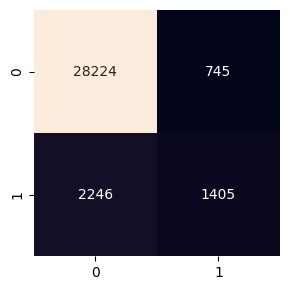

In [170]:
titanic_cm = confusion_matrix(y_train, y_pred)

# Dibujaremos esta matriz para hacerla más visual
cm_df = pd.DataFrame(titanic_cm)

plt.figure(figsize = (3, 3))
sns.heatmap(cm_df, annot=True, fmt="d", cbar=False)

plt.tight_layout()

plt.show()

## Busquedad de Hiperparametos

In [171]:
# Definimos los parámetros que queremos ajustar a mano
hyperparams = {
    "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
    "penalty": ["l1", "l2", "elasticnet", None],
    "solver": ["newton-cg", "lbfgs", "liblinear", "sag", "saga"]
}

# Inicializamos la cuadrícula
grid = GridSearchCV(model, hyperparams, scoring = "accuracy", cv = 5)
grid

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.001, 0.01, ...], 'penalty': ['l1', 'l2', ...], 'solver': ['newton-cg', 'lbfgs', ...]}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [182]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

grid.fit(X_train_sel, y_train)

print(f"Mejores hiperparámetros: {grid.best_params_}")

Mejores hiperparámetros: {'C': 0.1, 'penalty': 'l1', 'solver': 'saga'}


In [188]:
model = LogisticRegression(max_iter=1000, random_state=42, penalty = "l1", C = 0.1, solver = "saga", l1_ratio= 0.5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_train_sel)
accuracy_score(y_train, y_pred)

0.9082771305947271

Al realizar la busqueda de hiperparamentros tenemos que estos hacen que el modelo prediga un poco menos que sin estos.

In [ ]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_sel, y_train)

model = LogisticRegression(max_iter=1000, random_state=42, penalty = "l1", C = 0.1, solver = "saga", l1_ratio= 0.5)
model.fit(X_train_sel, y_train)
y_pred = model.predict(X_train_sel)



===== Resultados del Modelo Logistic Regression =====

Accuracy en test: 0.8867

Matriz de Confusión:
[[7149   64]
 [ 860   82]] 

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.89      0.99      0.94      7213
           1       0.56      0.09      0.15       942

    accuracy                           0.89      8155
   macro avg       0.73      0.54      0.55      8155
weighted avg       0.85      0.89      0.85      8155

ROC AUC: 0.5978


# Identificacion de overfiting

In [200]:

def get_metrics(yhat, y_test, yhat_train, y_train):
  metrics_train = r2_score(y_train, yhat_train), median_absolute_error(y_train, yhat_train), mean_absolute_percentage_error(y_train, yhat_train)*100
  metrics_test = r2_score(y_test, yhat), median_absolute_error(y_test, yhat), mean_absolute_percentage_error(y_test, yhat)*100
  metrics_diff = list(map(lambda x: x[1]-x[0], zip(metrics_train, metrics_test)))
  return pd.DataFrame(data=[metrics_train, metrics_test, metrics_diff], columns=['R2', 'Median AE', 'MAPE'], index=['Train set', 'Test set', 'Diferencia'])


yhat_train1_pred = np.exp(best_model.predict(X_train_sc1))
yhat_val_pred = np.exp(best_model.predict(X_val_sc))

metrics_1 = get_metrics(yhat_val_pred, np.exp(y_val), yhat_train1_pred, np.exp(y_train1))
metrics_1

,R2,Median AE,MAPE
Train set,0.076,0.000,8.290
Test set,0.081,0.000,8.165
Diferencia,0.005,0.000,-0.126
